# Zachary's Karate Club

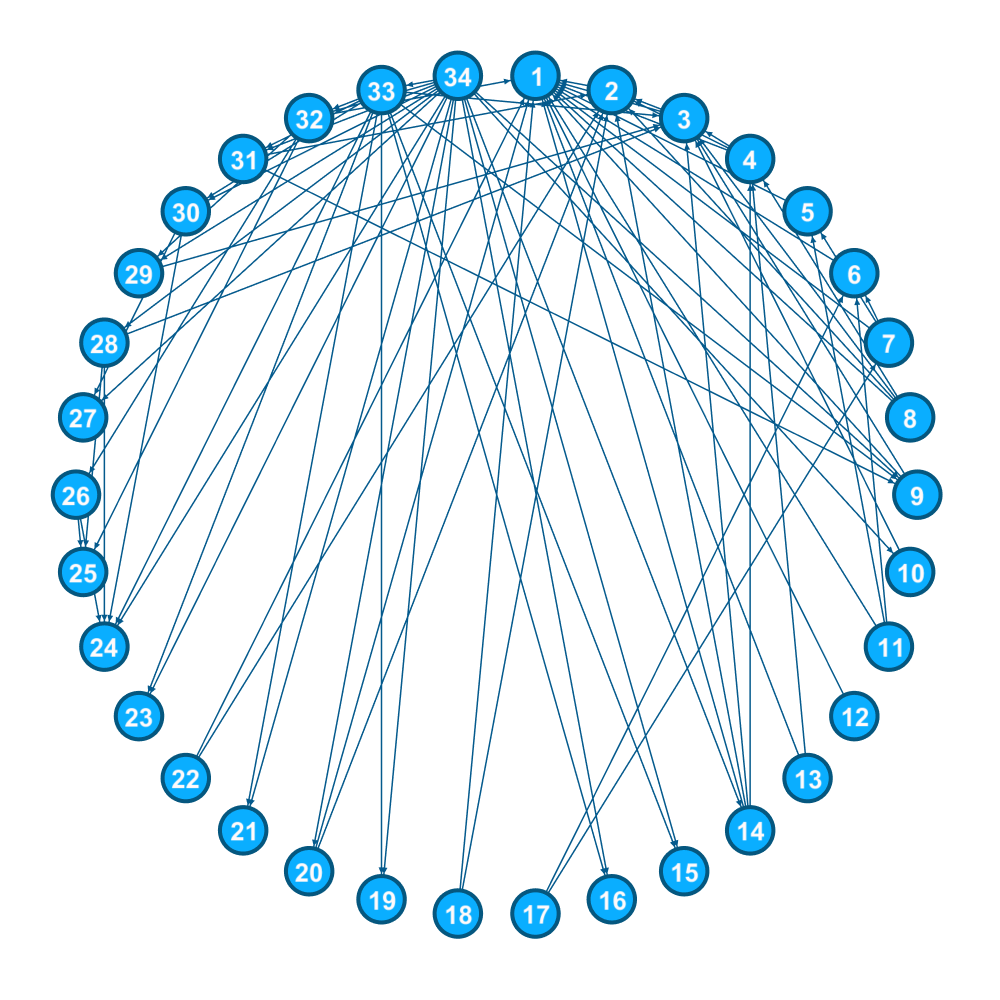

Zachary's karate club (ZKC) is a social network of a university karate club, described in the paper "An Information Flow Model for Conflict and Fission in Small Groups" by Wayne W. Zachary. 

The social network captures 34 members of a karate club, documenting links between pairs of members who interacted outside the club. 

During the study, a conflict arose between the officer/ administrator ("John A") and the instructor "Mr. Hi", which led to the split of the club into two. 

Part of the members formed a new club around Mr. Hi; and the remaining members went with the officer.

Based on collected data Zachary correctly assigned all but one member of the club to the groups they actually joined after the split. You could read more about it here https://en.wikipedia.org/wiki/Zachary%27s_karate_club, here https://www.jstor.org/stable/3629752, and here https://commons.wikimedia.org/wiki/File:Social_Network_Model_of_Relationships_in_the_Karate_Club.png

#### Import dependencies
Run this notebook on a standard Colab CPU runtime; no GPU or external dataset download is required. Complete each TODO before running its dependent cells. The setup cell installs a dependency only if it is missing. This exercise introduces graph neural networks; the definitions and matrix shapes below are needed before the first GNN lecture on October 8.


In [ ]:
import importlib.util
import subprocess
import sys

missing = [name for name in ('numpy', 'networkx', 'matplotlib')
           if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])

import numpy as np
import networkx as ntwx
import matplotlib.pyplot as plt

print('NumPy', np.__version__, '| NetworkX', ntwx.__version__)
%matplotlib inline


In [ ]:
def set_seed(seed=100):
    """sets seed"""
    np.random.seed(seed)

#### Processing Helper Functions

In [ ]:
def get_graph_metadata(graph, key=None):
    """Return graph size and, optionally, a dictionary of node attributes."""
    if key is None:
        return graph.number_of_nodes(), graph.number_of_edges()
    return graph.number_of_nodes(), graph.number_of_edges(), ntwx.get_node_attributes(graph, key)


def get_xavier_init(input_dim, output_dim):
    """Glorot/Xavier uniform initialization (variance 2 / (fan_in + fan_out))."""
    bound = np.sqrt(6.0 / (input_dim + output_dim))
    return np.random.uniform(-bound, bound, size=(input_dim, output_dim))


def get_cross_entropy(pred, labels):
    """Return one cross-entropy value per node; labels are one-hot vectors."""
    probs = np.clip(np.asarray(pred), np.finfo(float).tiny, 1.0)
    return -np.sum(labels * np.log(probs), axis=1)


def normalized_difference_norm(gradient, approximation):
    denominator = max(np.linalg.norm(gradient) + np.linalg.norm(approximation), 1e-12)
    return np.linalg.norm(gradient - approximation) / denominator


def get_colors_labels_and_classes(graph, num_nodes):
    """Use observed club affiliation: 0 = Mr. Hi, 1 = Officer."""
    class_by_club = {'Mr. Hi': 0, 'Officer': 1}
    colors = np.array([class_by_club[graph.nodes[i]['club']] for i in range(num_nodes)])
    return colors, np.eye(2)[colors], 2


def get_affiliation(club_labels):
    Mr_Hi = [i for i, club in club_labels.items() if club == 'Mr. Hi']
    Officer = [i for i, club in club_labels.items() if club == 'Officer']
    return Mr_Hi, Officer


def fill_diagonal(source_array, diagonal):
    copy = source_array.copy()
    np.fill_diagonal(copy, diagonal)
    return copy


The [NetworkX dataset documentation](https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.karate_club_graph.html) describes the `club` labels and interaction-count edge weights. We use the actual club labels as targets and deliberately ignore the edge weights, giving an unweighted graph. Node IDs in this notebook run from 0 to 33.


#### Visualization Helper Function

In [ ]:
def show_graph(graph, label_values_of_nodes, label_colors_of_nodes,
               colors_of_edges='black', display_window_size=10,
               positions_of_nodes=None, cmap='coolwarm'):
    fig, ax = plt.subplots(figsize=(display_window_size, display_window_size))
    if positions_of_nodes is None:
        positions_of_nodes = ntwx.spring_layout(graph, seed=100, weight=None)
    ntwx.draw(graph, positions_of_nodes,
              with_labels=label_values_of_nodes is not None,
              labels=label_values_of_nodes,
              node_color=label_colors_of_nodes, ax=ax,
              cmap=plt.get_cmap(cmap), edge_color=colors_of_edges)
    plt.show()


def plot_training_curves(train_losses, test_losses, accuracies, grid=False):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].semilogy(train_losses, label='train')
    axes[0].semilogy(test_losses, label='test (diagnostic only)')
    axes[0].set(xlabel='Epoch', ylabel='Mean cross-entropy')
    axes[1].plot(accuracies, label='test accuracy')
    axes[1].set(xlabel='Epoch', ylabel='Accuracy', ylim=[0, 1])
    for ax in axes:
        ax.legend()
        ax.grid(grid)
    plt.tight_layout()
    plt.show()


#### Gradient Update Helper Function

In [ ]:
def compute_gradients(param_name, layer, inputs_data, gt_labels,
                      eps=1e-5, weight_decay=0, training_nodes=None):
    """Central finite differences for mean labeled-node CE plus L2 on W only."""
    nodes = (np.arange(len(gt_labels)) if training_nodes is None
             else np.asarray(training_nodes, dtype=int))
    original = getattr(layer, param_name).copy()
    approximation = np.zeros_like(original)
    def objective(parameter):
        pred = layer.forward_pass(*inputs_data, **{param_name: parameter})
        W = parameter if param_name == 'W' else layer.W
        return (get_cross_entropy(pred, gt_labels)[nodes].mean()
                + weight_decay * np.sum(W ** 2) / (2 * len(nodes)))
    for index in np.ndindex(original.shape):
        lower, upper = original.copy(), original.copy()
        lower[index] -= eps
        upper[index] += eps
        approximation[index] = (objective(upper) - objective(lower)) / (2 * eps)
    layer.forward_pass(*inputs_data)  # restore caches at the unperturbed weights
    return approximation


#### Grad Descent Optimizer Helper Function

In [ ]:
class Grad_Descent_Optimizer:
    """Gradient-descent settings and shared backward-pass state."""
    def __init__(self, learning_rate, weight_decay):
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.output = None

    def __call__(self, y_pred, y_true, nodes_to_be_used_for_training=None):
        self.y_pred = np.asarray(y_pred)
        self.y_true = np.asarray(y_true)
        nodes = (np.arange(len(y_pred)) if nodes_to_be_used_for_training is None
                 else np.asarray(nodes_to_be_used_for_training, dtype=int))
        if (nodes.ndim != 1 or len(nodes) == 0 or len(np.unique(nodes)) != len(nodes)
                or np.any(nodes < 0) or np.any(nodes >= len(y_pred))):
            raise ValueError('Training node IDs must be nonempty, unique, and in range.')
        self.nodes_to_be_used_for_training = nodes
        # Only the labeled training nodes contribute to the mean objective.
        self.batch_size = len(nodes)


#### Set seed

In [ ]:
set_seed()

#### Implementation Check Helper Function

In [ ]:
def implementation_check(dW, dW_approx, db, db_approx):
    errors = (normalized_difference_norm(dW, dW_approx),
              normalized_difference_norm(db, db_approx))
    print('Relative gradient errors (W, bias):', errors)
    assert max(errors) < 1e-6, 'Gradient check failed.'
    print('Gradient check passed.')


#### Training Helper Function

In [ ]:
def train_test_split(test_nodes, labels):
    test_nodes = np.asarray(test_nodes, dtype=int)
    assert len(test_nodes) == len(np.unique(test_nodes))
    assert np.all((0 <= test_nodes) & (test_nodes < len(labels)))
    return np.setdiff1d(np.arange(len(labels)), test_nodes)


#### Node Classification Helper Function

In [ ]:
class Softmax_Layer:
    """Per-node linear classifier followed by softmax over classes."""
    def __init__(self, input_dim, output_dim, name=''):
        self.name, self.cache = name, {}
        self.input_dim, self.output_dim = input_dim, output_dim
        self.bias = np.zeros((output_dim, 1))
        self.W = get_xavier_init(output_dim, input_dim)

    def __repr__(self):
        return f'Softmax_Layer {self.name}: W{self.W.shape}'

    def get_softmax(self, logits):
        exp_logits = np.exp(logits - np.max(logits, axis=0, keepdims=True))
        return exp_logits / exp_logits.sum(axis=0, keepdims=True)

    def forward_pass(self, X, W=None, bias=None):
        self.cache['X'] = np.asarray(X).T
        W = self.W if W is None else W
        bias = self.bias if bias is None else bias
        return self.get_softmax(W @ self.cache['X'] + bias).T

    def backward_pass(self, optimizer, need_update=True):
        dLoss = np.zeros_like(optimizer.y_pred)
        nodes = optimizer.nodes_to_be_used_for_training
        dLoss[nodes] = optimizer.y_pred[nodes] - optimizer.y_true[nodes]
        # Propagate gradients of the summed CE; each parameter gradient divides by m.
        self.grad = dLoss @ self.W
        optimizer.output = self.grad
        dW = (dLoss.T @ self.cache['X'].T + optimizer.weight_decay * self.W) / optimizer.batch_size
        dbias = dLoss.sum(axis=0).reshape(self.bias.shape) / optimizer.batch_size
        if need_update:
            self.W -= optimizer.learning_rate * dW
            self.bias -= optimizer.learning_rate * dbias
        return dW, dbias


### ZKC

We predict the two observed club affiliations with a graph convolutional network (GCN). Training uses the labels of some nodes; the remaining labels are held out. All graph edges and node features are visible for message passing. This is **transductive node classification**, not unsupervised clustering.

A graph's **adjacency matrix** has $A_{ij}=1$ when nodes $i$ and $j$ share an edge and is zero otherwise. We add self loops, $\tilde A=A+I$, so each node can use its own features as well as its neighbors'. Define the diagonal degree matrix by $\tilde D_{ii}=\sum_j\tilde A_{ij}$ and the normalized adjacency $\hat A=\tilde D^{-1/2}\tilde A\tilde D^{-1/2}$. Degree normalization rescales messages; self loops include a node's own message and ensure positive degrees.

Following [Kipf and Welling](https://arxiv.org/abs/1609.02907), each layer computes
$$H^{(\ell+1)}=\tanh(\hat A H^{(\ell)}(W^{(\ell)})^T).$$
Here $H^{(\ell)}$ has shape `(num_nodes, input_dim)` and our implementation stores $W^{(\ell)}$ with shape `(output_dim, input_dim)`. The paper uses the transposed weight convention. Matrix multiplication by $\hat A$ aggregates neighboring node features, then the shared weight matrix changes the feature dimension, and `tanh` acts elementwise. A final per-node linear/softmax layer predicts probabilities for the two classes.


We used the python module networkx to import the dataset and provided some helper functions to help understand the data as shown below.

In [ ]:
graph = ntwx.karate_club_graph()
num_nodes, num_edges, club_labels = get_graph_metadata(graph, 'club')
colors, labels, num_classes = get_colors_labels_and_classes(graph, num_nodes)
Mr_Hi_people, Officer_people = get_affiliation(club_labels)

### Data Inspection

In [ ]:
print(f'ZKC dataset graph has {num_nodes} nodes and {num_edges} edges')

In [ ]:
print(f'The affiliation of each of the 34 members between the officer and Mr. Hi is given below:\n {club_labels}')

In [ ]:
print(f'nodes/people loyal to Mr. Hi are:\n {Mr_Hi_people}')

In [ ]:
print(f'nodes/people loyal to the officer are:\n {Officer_people}')

In [ ]:
assert len(Officer_people) + len(Mr_Hi_people) == num_nodes

Nodes represent people and edges represent social interactions outside the club. The colors below show the true observed affiliation (`0 = Mr. Hi`, `1 = Officer`); they are not model predictions. They are shown for inspection only and must not all be used as training labels.


##### Show Graph with Labels

In [ ]:
show_graph(graph=graph,
           label_values_of_nodes=club_labels,
           label_colors_of_nodes=colors,
           colors_of_edges='black',
           positions_of_nodes=None)

##### Show Graph without Labels

In [ ]:
show_graph(graph=graph,
           label_values_of_nodes=None,
           label_colors_of_nodes=colors,
           colors_of_edges='black',
           positions_of_nodes=None,)

The target labels are the observed `club` attributes from NetworkX. We do not infer these labels with community detection.


Implement a NumPy GNN for node classification. We also plot the final two-dimensional hidden features (embeddings). Cross-entropy trains a classifier; it does not directly minimize within-class Euclidean distance, so visual proximity is not a classification rule.


In [ ]:
A = ntwx.to_numpy_array(graph, nodelist=range(num_nodes), weight=None, dtype=float)
assert np.allclose(A, A.T) and np.all(np.diag(A) == 0)
A


The adjacency matrix has zeros on its diagonal, so its aggregation excludes the node itself. We want our network to be aware of information about the nodes themselves instead of only the neighborhood, so we add self loops to our adjacency matrix. The paper called this $\tilde A$.

#### Q. 1. Compute: $$\tilde{A}=A_{self-loop}= A + I$$
Here $I$ is the identity matrix, adding one self loop to each node.

In [ ]:
# TODO
# A_tild = ????

#### Q.2. Return $\hat A=\tilde D^{-1/2}\tilde A\tilde D^{-1/2}$ from `get_adjacency_matrix(A_tild)`.
The degree is the row sum of $\tilde A$, including the self loop. Since $\tilde D$ is diagonal, its inverse square root simply has diagonal entries $1/\sqrt{\tilde D_{ii}}$. Use elementwise `np.sqrt` and diagonal matrices or broadcasting; no general matrix inverse or matrix square root is needed.


In [ ]:
def get_adjacency_matrix(A_tild):
    # TODO
    return 

In [ ]:
A_hat = get_adjacency_matrix(A_tild)
A_hat

The node-feature matrix `X` has one row per node. We have no external node features here, so use the identity matrix: each row is a one-hot node ID. With our `(output_dim, input_dim)` weight convention, the first-layer weights contain one learnable column per node, and aggregation mixes these columns. This is suitable for this fixed graph; it does not provide features for previously unseen node IDs.


##### Q.3. Generate the feature input matrix $X$

In [ ]:
# TODO
# X = ??

#### Single GNN Layer Implementation

Implement forward and backward passes for $H=\tanh(\hat A X W^T)$. Cache the aggregated input and activation. In reverse mode, backpropagating through multiplication by $\hat A$ requires $\hat A^T$ (equal to $\hat A$ for this undirected graph).

For a training set $T$ of $m$ labeled nodes, the complete training objective is
$$L=\frac1m\sum_{i\in T}-\log p_{i,y_i}+\frac{\alpha}{2m}\sum_{\text{layers}}\|W\|_F^2.$$
Here `alpha = optimizer.weight_decay`. Biases are not regularized. Consequently, each layer adds `alpha * W / m` to its weight gradient. `optimizer.output` carries the gradient of the **sum** of the labeled-node cross-entropies, so divide each parameter gradient by `optimizer.batch_size = m` exactly once. Unlabeled nodes can still affect labeled predictions through message passing; mask only the output-label loss, not the hidden gradients.


#### Q.4. Complete the TODOs for the GNN layer's forward and backward passes.


In [ ]:
class GNN_Layer():
    """process a single GNN layer"""
    def __init__(self, input_dim, output_dim, name=''):
        self.name = name
        self.cache = {}
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.W = get_xavier_init(self.output_dim, self.input_dim)
        self.activation = np.tanh
        
    def __repr__(self):
        dims = (self.input_dim, self.output_dim)
        if self.name:
            return f"GNN_Layer: W{'_' + self.name}{dims}"
        else:
            return f"GNN_Layer: W{'_'+ ''}{dims}"
        
    def forward_pass(self, A, X, W=None):
        """A here is the symmetrically normalized adjacency matrix
        and X is the input to the layer. We cached some values 
        to use in the backward pass."""
        
        self.cache['A'] = A # (batch_size, batch_size)
        # TODO 
        # self.cache['X'] = ?? # (input_node_feature_dim, batch_size)
        
        # if W is None:
            # W = ??
        
        # H = ?? (hidden_dim, batch_size)
        # H = ??  (apply activation)
        # self.cache['H'] = ?? # (hidden_dim, batch_size)
        return # (batch_size, hidden_dim)
    
    def backward_pass(self, optimizer, need_update=True):
        # dtanh = ?? # (batch_size, output_dim)
        # optimizer.output contains the gradient from the next layer. It is multiplied by the number of labeled training nodes,
        # so you'll need to divide by optimizer.batch_size to get the average gradient.
        d = np.multiply(optimizer.output, dtanh) # (batch_size, output_dim)
        
        # self.grad = ?? (batch_size, input_dim)
        
        optimizer.output = self.grad
        
        # dW = ?? # (output_dim, input_node_feature_dim)
        # dW_weight_decay = ??
        
        # if need_update: # Use the gradient descent update rule on W. Remember to include weight decay.
            # self.W = ??
        
        return # (output_dim, input_node_feature_dim)

The final classifier applies the same linear map and softmax independently to each node's learned embedding. That final layer does no further message passing; its implementation is provided above.


#### Test your implementation


lets's instantiate the GNN_Layer Class and the Softmax_Layer provided in the helper functions to test the gradients.

In [ ]:
gnn_layer = GNN_Layer(input_dim=num_nodes,
                output_dim=2,
                name='gnn_layer_1')

sm_layer = Softmax_Layer(input_dim=2,
                   output_dim=num_classes,
                   name='softmax_layer')

optim = Grad_Descent_Optimizer(learning_rate=0,
                               weight_decay=1.)

####  Q. 5. lets compute the forward passes, uncomment and complete

In [ ]:
# TODO
# gnn_layer_output = gnn_layer.forward_pass(A=??,
#                                           X=??)

# optim(y_pred=sm_layer.forward_pass(X=gnn_layer_output), y_true=labels)

lets verify that the layers are properly implemented by looking at the gradients. Note that need update is used only when we are updating the parameters during training. We do not need to do so here since we are just testing our layers.

In [ ]:
dW_approx = compute_gradients(param_name="W",
                              layer=sm_layer,
                              inputs_data=(gnn_layer_output,),          
                              gt_labels=labels,
                              eps=1e-4,
                              weight_decay=optim.weight_decay)

db_approx = compute_gradients(param_name="bias",
                              layer=sm_layer,
                              inputs_data=(gnn_layer_output,),
                              gt_labels=labels,
                              eps=1e-4,
                              weight_decay=optim.weight_decay)

In [ ]:
dW, db = sm_layer.backward_pass(optim, need_update=False)

The following checks compare analytic gradients with central finite differences. They test both the provided classifier and your GNN layer, including a subset of labeled nodes.


In [ ]:
dW, db = sm_layer.backward_pass(optim, need_update=False)

#### We now assert that the true and approximate gradients are very close to each other. If not, something went wrong in our implementation.

In [ ]:
implementation_check(dW, dW_approx, db, db_approx)

In [ ]:
# Test a tiny graph, including hidden gradients through held-out nodes.
def check_gnn_gradients():
    rng_state = np.random.get_state()
    np.random.seed(7)
    adjacency = np.array([[1., 1., 0.], [1., 1., 1.], [0., 1., 1.]])
    degrees = adjacency.sum(axis=1)
    normalized = adjacency / np.sqrt(degrees[:, None] * degrees[None, :])
    features = np.array([[.2, -.3], [.5, .1], [-.4, .8]])
    targets = np.eye(2)[[0, 1, 0]]
    nodes = np.array([0, 2])
    gcn = GNN_Layer(2, 2)
    classifier = Softmax_Layer(2, 2)
    opt = Grad_Descent_Optimizer(0., .07)
    def objective():
        prob = classifier.forward_pass(gcn.forward_pass(normalized, features))
        return (get_cross_entropy(prob, targets)[nodes].mean()
                + opt.weight_decay * (np.sum(gcn.W**2) + np.sum(classifier.W**2)) / (2*len(nodes)))
    probability = classifier.forward_pass(gcn.forward_pass(normalized, features))
    opt(probability, targets, nodes)
    classifier.backward_pass(opt, need_update=False)
    analytical = gcn.backward_pass(opt, need_update=False)
    numerical = np.zeros_like(gcn.W)
    eps = 1e-5
    for index in np.ndindex(gcn.W.shape):
        original = gcn.W[index]
        gcn.W[index] = original + eps
        upper = objective()
        gcn.W[index] = original - eps
        lower = objective()
        gcn.W[index] = original
        numerical[index] = (upper-lower)/(2*eps)
    error = normalized_difference_norm(analytical, numerical)
    print('Masked GNN relative gradient error:', error)
    assert error < 1e-6
    # Changing held-out labels cannot change a training gradient.
    probability = classifier.forward_pass(gcn.forward_pass(normalized, features))
    changed_targets = targets.copy()
    changed_targets[1] = changed_targets[1, ::-1]
    opt(probability, changed_targets, nodes)
    classifier.backward_pass(opt, need_update=False)
    unchanged = gcn.backward_pass(opt, need_update=False)
    np.testing.assert_allclose(analytical, unchanged, rtol=1e-12, atol=1e-12)
    np.random.set_state(rng_state)
    print('GNN gradient and held-out-label masking checks passed.')

check_gnn_gradients()


#### Q.6. Assemble the GNN and softmax layers.
`num_layers` is the number of graph-convolution layers, and `hidden_dim` contains exactly one output width per graph-convolution layer. For `hidden_dim=[16, 2]`, use `input_dim -> 16 -> 2`, then a linear/softmax classifier `2 -> output_dim`.


In [ ]:
class GNN():
    """This class leverages the GNN layer implemanted above by cascading them into a layer."""
    def __init__(self,
                 input_dim,
                 output_dim,
                 hidden_dim,
                 num_layers,):
        
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.layers = []
#         first_gnn_layer = GNN_Layer(input_dim=??,
#                                   output_dim=??,
#                                   name='layer_0')
        
        self.layers.append(first_gnn_layer)
        
#         for layer in range(1, num_layers):
#             gnn_temp = GNN_Layer(input_dim=??,
#                                  output_dim=??,
#                                  name=f'layer_{layer}')
#             self.layers.append(gnn_temp)
            
 
#         last_gnn_layer = Softmax_Layer(input_dim=??,
#                                output_dim=??,
#                                name='sm_layer')
#         self.layers.append(last_gnn_layer)
        
    def __repr__(self):
        return '\n'.join([str(layer) for layer in self.layers])
    
    def embedding(self, A, X):
        H = X
        for layer in self.layers[:-1]:
            # H = ??
            pass
        # return 
    
    def forward_pass(self, A, X):
        # H = ??
        out = self.layers[-1].forward_pass(H)
        pass
        # return 

#### Q.7. uncomment and complete

In [ ]:
# TODO
# gnn_model = GNN(
#     input_dim=??, 
#     output_dim=??, 
#     num_layers=2,
#     hidden_dim=[16, 2], 
# )
# gnn_model

#### Train/ Test split

The 10 test nodes are 0, 1, 3, 8, 15, 16, 20, 25, 28, and 30. The remaining 24 nodes are used for training. IDs are unique, and training and test sets are disjoint. We fix the epoch budget in advance. Test curves are post-hoc diagnostics: do not use them to choose when to stop or tune hyperparameters; doing so would require a separate validation split.


In [ ]:
test_nodes = np.array([0, 1, 3, 8, 15, 16, 20, 25, 28, 30])
train_nodes = train_test_split(test_nodes, labels)
assert len(train_nodes) == 24 and len(test_nodes) == 10
assert len(np.intersect1d(train_nodes, test_nodes)) == 0


In [ ]:
print(f'The nodes that will be used for training are:\n {train_nodes}')

In [ ]:
print(f'The held-out test nodes are:\n {test_nodes}')


We now instantiate our optimizer with a learning rate and weight decay for training.

In [ ]:
training_optim = Grad_Descent_Optimizer(learning_rate=2e-2, weight_decay=2.5e-2)

#### Q.8. Complete the training loop.
Compute predictions, update parameters using only the training-node label loss, and then recompute predictions at the updated weights. Store embeddings and predictions from the same weights. Report train and test mean cross-entropies on their respective sets. Use the fixed 5,000-epoch budget; do not stop based on test loss.


In [ ]:
def train(model, A_hat, X, y_true, nodes_to_be_used_for_training,
          nodes_to_be_used_for_testing, optimizer, num_epochs=5000):
    train_nodes = np.asarray(nodes_to_be_used_for_training, dtype=int)
    test_nodes = np.asarray(nodes_to_be_used_for_testing, dtype=int)
    assert len(np.intersect1d(train_nodes, test_nodes)) == 0
    training_losses, testing_losses, accs, embeddings, y_preds = [], [], [], [], []
    for epoch in range(num_epochs):
        y_pred = None  # TODO: compute probabilities for all nodes
        optimizer(y_pred, y_true, train_nodes)
        for layer in reversed(model.layers):
            layer.backward_pass(optimizer, need_update=True)
        # Recompute at the updated weights so metrics and embeddings agree.
        y_pred = None  # TODO: compute probabilities for all nodes
        embedding = model.embedding(A_hat, X)
        loss_per_node = None  # TODO: compute one cross-entropy per node
        train_loss = None  # TODO: mean over training nodes
        test_loss = None  # TODO: mean over test nodes
        training_losses.append(train_loss)
        testing_losses.append(test_loss)
        accs.append(np.mean(y_pred[test_nodes].argmax(axis=1)
                            == y_true[test_nodes].argmax(axis=1)))
        embeddings.append(embedding.copy())
        y_preds.append(y_pred.copy())  # keep probabilities; argmax gives classes
        if epoch % 1000 == 0:
            print(f'epoch {epoch + 1}: train CE={train_loss:.4f}; test CE={test_loss:.4f}')
    return (np.asarray(training_losses), np.asarray(testing_losses),
            np.asarray(accs), np.asarray(embeddings), np.asarray(y_preds))


In [ ]:
training_losses, testing_losses, accs, embeddings, preds = train(
    model=gnn_model, A_hat=A_hat, X=X, y_true=labels,
    nodes_to_be_used_for_training=train_nodes,
    nodes_to_be_used_for_testing=test_nodes,
    optimizer=training_optim, num_epochs=5000)


In [ ]:
predicted_classes = preds[-1].argmax(axis=1)
true_classes = labels.argmax(axis=1)
for split_name, node_ids in [('train', train_nodes), ('test', test_nodes)]:
    correct = predicted_classes[node_ids] == true_classes[node_ids]
    print(f'{split_name} accuracy: {correct.mean():.1%}; '
          f'misclassified node IDs: {node_ids[~correct].tolist()}')


In [ ]:
plot_training_curves(training_losses, testing_losses, accs)

#### Results

Let's observe the affiliation of people in our test nodes.

In [ ]:
[club_labels[i] for i in test_nodes]

Let's inspect the two-dimensional embeddings of the test nodes.


In [ ]:
embeddings[-1][test_nodes]

Let's inspect the true one-hot affiliation labels of the test nodes.


In [ ]:
labels[test_nodes]

Let's inspect the model's predicted class probabilities for the test nodes.


In [ ]:
preds[-1][test_nodes]

Finally, plot all node embeddings, colored by their true affiliation. These positions are learned features, not predicted class labels. Judge classification errors using `argmax` of the softmax output above.


In [ ]:
show_graph(graph=graph,
           label_values_of_nodes=club_labels,
           label_colors_of_nodes=colors,
           colors_of_edges='black',
           positions_of_nodes={i: embeddings[-1][i,:] \
                               for i in range(embeddings[-1].shape[0])},
          )

#### Q.9. Report the final training and test accuracies and list any misclassified node IDs.
Does a node lying near the other class in the embedding plot necessarily mean that the classifier misclassified it? Explain using the predicted classes. Is 100% test accuracy guaranteed for this experiment?
